### Load Data

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import normaltest
from scipy.stats import linregress

# Set display options to show all columns and rows (but with scrollbars)
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.float_format', '{:,.0f}'.format)

In [2]:
ebird = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/ebd_US-WI-025_201501_202501_smp_relFeb-2025/ebd_US-WI-025_201501_202501_smp_relFeb-2025.txt', sep='\t')

/var/folders/3w/875q3kbn2blb9zwp1zjfrhfc0000gn/T/ipykernel_4910/1578680948.py:1: DtypeWarning: Columns (7,8,9,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  ebird = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/ebd_US-WI-025_201501_202501_smp_relFeb-2025/ebd_US-WI-025_201501_202501_smp_relFeb-2025.txt', sep='\t')


In [28]:
prism_WI_dane_county = pd.read_csv('/Users/silviaaaaaa/Desktop/ebird data analysis/Data/PRISM_ppt_tmin_tmean_tmax_provisional_800m_20150101_20250131_43.0674_-89.4183.csv', skiprows=10)

### Describe ebird Data

In [4]:
# Summary for data of WI, Dane county,  Date between 2015-01-01 and 2025-01-31

# Top 3 most observed birds: Canada Goose, American Coot, Mallard
# Top 3 most diverse sites: Nine Springs Natural Area (318 species), UW Lakeshore Nature Preserve (general) (312 species), UW Madison Arboretum (general) (295 species). Combined they host 80.4% of all 465 observed species.
# Top 3 sites by abundance: Nine Springs Natural Area, Lake Farm County Park, UW Madison Arboretum (general). Combined they host 14.6% of all observed birds.
# Top 3 birding hotspots (using unique count of submitted checklists): UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park. These locations account for 7.4% of all 309857 checklists submitted.
# 51% of checklists are Traveling, 30% are Stationary
# Birders typically begin their outings around 5 AM. Checklist submissions spike sharply between 7-8 AM, then gradually decline through late morning. Activity stabilizes from noon to 4 PM, before tapering off as daylight fades in the evening.
# 95% of checklists have duration <= 3.2 hour and 6 km

In [5]:
ebird.head()

,GLOBAL UNIQUE IDENTIFIER,LAST EDITED DATE,TAXONOMIC ORDER,CATEGORY,TAXON CONCEPT ID,COMMON NAME,SCIENTIFIC NAME,SUBSPECIES COMMON NAME,SUBSPECIES SCIENTIFIC NAME,EXOTIC CODE,OBSERVATION COUNT,BREEDING CODE,BREEDING CATEGORY,BEHAVIOR CODE,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,IBA CODE,BCR CODE,USFWS CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,OBSERVER ID,SAMPLING EVENT IDENTIFIER,PROTOCOL TYPE,PROTOCOL CODE,PROJECT CODE,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,NUMBER OBSERVERS,ALL SPECIES REPORTED,GROUP IDENTIFIER,HAS MEDIA,APPROVED,REVIEWED,REASON,TRIP COMMENTS,SPECIES COMMENTS,Unnamed: 49
0,URN:CornellLabOfOrnithology:EBIRD:OBS294566730,2017-07-17 13:48:19,8209,spuh,avibase-CA08045E,Accipitrine hawk sp. (former Accipiter sp.),Aerospiza/Tachyspiza/Accipiter/Astur sp.,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,US-WI_3635,23,NaN,NaN,WI - Prairie du Sac Wollersheim Winery,L3187307,P,43,-90,2015-01-31,15:00:00,obsr213338,S21647178,Stationary,P21,EBIRD,20,NaN,NaN,4,1,NaN,0,1,0,NaN,NaN,NaN,NaN
1,URN:CornellLabOfOrnithology:EBIRD:OBS293977598,2021-03-30 02:26:51.250642,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Dyreson Road Bridge,L2720718,P,43,-89,2015-01-30,10:27:00,obsr384920,S21600893,Stationary,P21,EBIRD,4,NaN,NaN,2,1,G1129663,0,1,0,NaN,"<br />Submitted from BirdLog NA for iOS, versi...",NaN,NaN
2,URN:CornellLabOfOrnithology:EBIRD:OBS294098919,2021-04-01 21:33:26.357322,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Babcock County Park,L662891,H,43,-89,2015-01-30,13:15:00,obsr151037,S21609879,Stationary,P21,EBIRD,30,NaN,NaN,4,1,G1129804,0,1,0,NaN,NaN,NaN,NaN
3,URN:CornellLabOfOrnithology:EBIRD:OBS292844052,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-23,16:32:00,obsr438170,S21510913,Stationary,P21,EBIRD,59,NaN,NaN,2,1,NaN,0,1,0,NaN,With Jude Vickery Submitted from BirdLog NA f...,NaN,NaN
4,URN:CornellLabOfOrnithology:EBIRD:OBS294268996,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-31,11:00:00,obsr381800,S21623656,Traveling,P22,EBIRD,40,3,NaN,1,1,NaN,0,1,0,NaN,NaN,NaN,NaN


In [6]:
ebird.shape

(4298659, 50)

In [7]:
ebird['OBSERVATION DATE'].agg(['min', 'max'])

min    2015-01-01
max    2025-01-31
Name: OBSERVATION DATE, dtype: object

#### Initial Cleaning

In [8]:
# initial cleaning
# drop irrelevant column - Unnamed: 49 
ebird = ebird.drop(columns=['Unnamed: 49'])
# drop non numeric values in OBSERVATION COUNT and convert to numeric
ebird_numeric_count_only = ebird[ebird['OBSERVATION COUNT'] != 'X'].dropna(subset=['OBSERVATION COUNT'])
ebird_numeric_count_only['OBSERVATION COUNT'] = pd.to_numeric(ebird_numeric_count_only['OBSERVATION COUNT'])

#### Missing Value

In [9]:
# columns with missing value
missing_pct = ebird.isnull().mean() * 100
missing_pct[missing_pct > 0]

SUBSPECIES COMMON NAME        99
SUBSPECIES SCIENTIFIC NAME    99
EXOTIC CODE                   93
BREEDING CODE                 97
BREEDING CATEGORY             97
BEHAVIOR CODE                 97
AGE/SEX                       99
IBA CODE                      87
USFWS CODE                    98
ATLAS BLOCK                   96
TIME OBSERVATIONS STARTED      1
DURATION MINUTES               5
EFFORT DISTANCE KM            26
EFFORT AREA HA               100
NUMBER OBSERVERS               1
GROUP IDENTIFIER              79
REASON                       100
TRIP COMMENTS                 86
SPECIES COMMENTS              96
dtype: float64

In [10]:
# ebird['CATEGORY'].isnull().mean() * 100
ebird['CATEGORY'].value_counts(normalize=True) * 100

CATEGORY
species      98
spuh          1
issf          1
domestic      0
slash         0
form          0
hybrid        0
intergrade    0
Name: proportion, dtype: float64

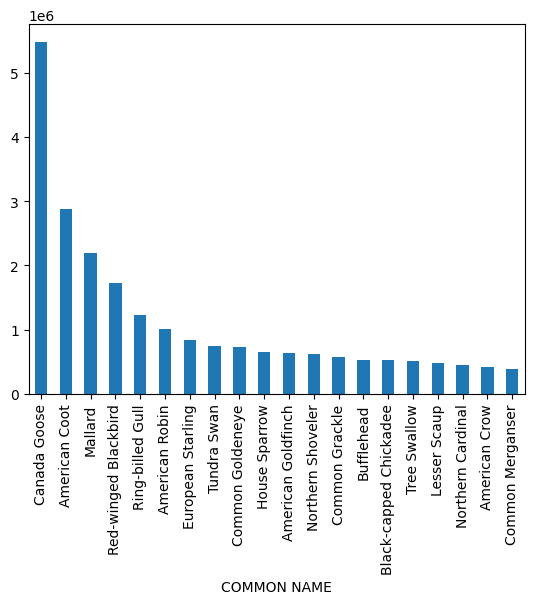

Top 3 most observed birds: Canada Goose, American Coot, Mallard


In [11]:
# convert OBSERVATION COUNT to numeric


# top species count

(ebird_numeric_count_only.groupby('COMMON NAME')['OBSERVATION COUNT'].sum().nlargest(20).plot(kind='bar'))
plt.show()

top_birds = (
    ebird_numeric_count_only.groupby('COMMON NAME')['OBSERVATION COUNT']
    .sum()
    .nlargest(3)
    .index.tolist()
)

print(f"Top 3 most observed birds: {', '.join(top_birds)}")

In [12]:
# Get unique species at each top site
site_diversity = ebird.groupby('LOCALITY')['COMMON NAME'].nunique().sort_values(ascending=False)
top_sites = site_diversity.head(3)
top_sites_list = site_diversity.head(3).index.tolist()
total_species = ebird['COMMON NAME'].nunique()
unique_species_in_top_sites = ebird[ebird['LOCALITY'].isin(top_sites_list)]['COMMON NAME'].nunique()

# Calculate percentage
pct_combined = round(unique_species_in_top_sites / total_species * 100)  

# Generate summary
summary = (
    f"Top 3 most diverse sites: " +
    ', '.join([f"{site} ({count} species)" for site, count in top_sites.head(3).items()]) +
    f".\nCombined they make up {pct_combined}% of all {total_species} observed species."
)

print(summary)

Top 3 most diverse sites: Nine Springs Natural Area (318 species), UW Lakeshore Nature Preserve (general) (312 species), UW Madison Arboretum (general) (295 species).
Combined they make up 80% of all 465 observed species.


In [13]:
# Calculate total abundance per site
site_abundance = ebird_numeric_count_only.groupby('LOCALITY')['OBSERVATION COUNT'].sum().nlargest(3)

# Calculate percentage of total abundance
total_abundance = ebird_numeric_count_only['OBSERVATION COUNT'].sum()
pct_combined = round(site_abundance.sum() / total_abundance * 100, 1)

# Generate summary
summary = (
    f"Top 3 sites by abundance: " +
    ', '.join([f"{site}" for site in site_abundance.index]) +
    f".\nCombined they host {pct_combined}% of all observed birds."
)

print(summary)

Top 3 sites by abundance: Nine Springs Natural Area, Lake Farm County Park, UW Madison Arboretum (general).
Combined they host 14.6% of all observed birds.


In [14]:
# Calculate unique checklists per site
hotspot_popularity = ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().sort_values(ascending=False)
top3_hotspots = hotspot_popularity.head(3)
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()
hotspot_pct = round(top3_hotspots.sum() / total_checklists * 100, 1)

# Generate summary
hotspot_summary = (
    f"Top 3 birding hotspots (using unique count of submitted checklists): " +
    ', '.join([f"{site}" for site in top3_hotspots.index]) +
    f".\nThese locations account for {hotspot_pct}% of all {total_checklists} checklists submitted."
)

print(hotspot_summary)

Top 3 birding hotspots (using unique count of submitted checklists): UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park.
These locations account for 7.4% of all 309857 checklists submitted.


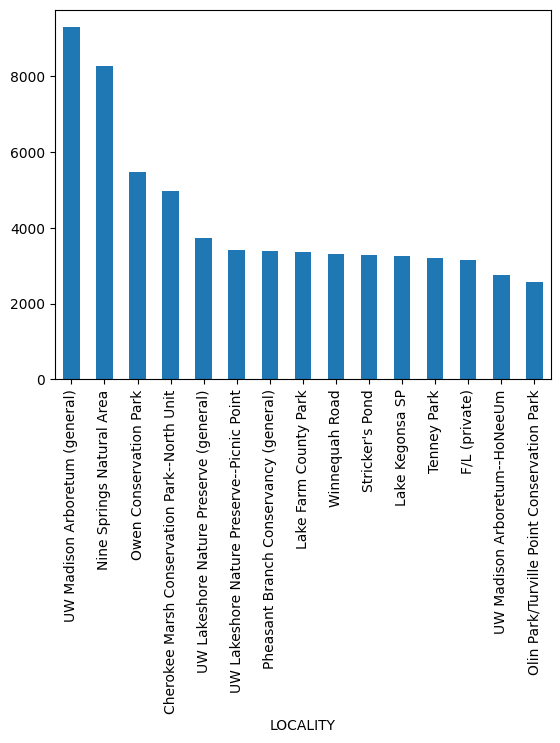

In [15]:
# top 15 hotspots
(ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().nlargest(15).plot(kind='bar'))
plt.show()

In [16]:
# Count UNIQUE checklists by protocol type
protocol_counts = ebird.groupby('PROTOCOL TYPE')['SAMPLING EVENT IDENTIFIER'].nunique()
total_checklists = protocol_counts.sum()

# Calculate percentages (whole numbers)
traveling_pct = int(round(protocol_counts.get('Traveling', 0) / total_checklists * 100))
stationary_pct = int(round(protocol_counts.get('Stationary', 0) / total_checklists * 100))

# Generate summary
print(f"{traveling_pct}% of checklists are Traveling, {stationary_pct}% are Stationary")

51% of checklists are Traveling, 30% are Stationary


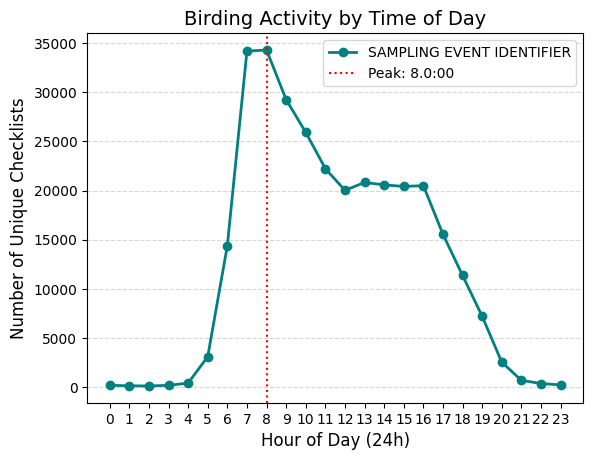

In [17]:
# Convert time to datetime and extract hour
ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED'], format='%H:%M:%S').dt.hour

# Count unique checklists per hour
hourly_counts = ebird.groupby('HOUR')['SAMPLING EVENT IDENTIFIER'].nunique()

# Plot line graph
plt.figure()
hourly_counts.plot(
    kind='line',
    marker='o',      # Add dots for each data point
    linestyle='-',    # Solid line
    linewidth=2,
    color='teal'
)

# Customize plot
plt.title('Birding Activity by Time of Day', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Unique Checklists', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight peak hours
peak_hour = hourly_counts.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle=':', label=f'Peak: {peak_hour}:00')
plt.legend()

plt.show()

In [18]:
# Calculate total unique checklists
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()

# Count checklists between 5-8 AM
morning_checklists = ebird[ebird['HOUR'].between(5, 8)]['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage
morning_percentage = (morning_checklists / total_checklists) * 100

print(f"{morning_percentage:.1f}% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.")

27.7% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.


#### Outlier

Outlier Observation Summary
1. Extreme Checklists Identified:

Prolonged Duration: ~0.6% of checklists exceed 12 hours (biologically implausible for most surveys).

Excessive Distance: ~0.6% surpass the 99th percentile (8.7 km) effort distance.

Combined Impact: These outliers collectively affect 1.1% of total checklists.

2. Analytical Implications:

Avoid mean-based metrics for duration/distance, as outliers skew results.

Recommended Approach:

Use median and quantiles (e.g., 75th/95th percentiles).

Filter extreme values (>12hr or >8.7km) for robust statistics.

In [19]:
suspect_cols = ['OBSERVATION COUNT', 'DURATION MINUTES', 'EFFORT DISTANCE KM', 'EFFORT AREA HA']


ebird[suspect_cols].describe(percentiles=[.01, .25, .5, .75, .95, .99])

,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA
count,"4,078,618","3,180,841","4,830"
mean,77,3,20
std,67,3,60
min,1,0,0
1%,4,0,0
25%,30,1,2
50%,60,2,2
75%,105,3,4
95%,191,6,97
99%,282,9,259


In [20]:
# Calculate 99th percentiles
thresholds = {
    'duration': 720,  # 12 hours
    'distance': ebird['EFFORT DISTANCE KM'].quantile(0.99),
    'area': ebird['EFFORT AREA HA'].quantile(0.99)
}

# Identify extreme checklists
extreme_flags = (
    ebird.groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        DURATION_EXTREME=('DURATION MINUTES', lambda x: x.max() > thresholds['duration']),
        DISTANCE_EXTREME=('EFFORT DISTANCE KM', lambda x: x.max() > thresholds['distance']),
        AREA_EXTREME=('EFFORT AREA HA', lambda x: x.max() > thresholds['area'])
    )
)

# Calculate percentages
total_checklists = extreme_flags.shape[0]
results = {
    'Any extreme': extreme_flags.any(axis=1).mean() * 100,
    'Duration only': extreme_flags['DURATION_EXTREME'].mean() * 100,
    'Distance only': extreme_flags['DISTANCE_EXTREME'].mean() * 100,
    'Area only': extreme_flags['AREA_EXTREME'].mean() * 100
}

# Print formatted results
print(f"{'Metric':<15} {'% of Checklists':>15}")
print("-" * 30)
for k, v in results.items():
    print(f"{k:<15} {v:>15.1f}%")

Metric          % of Checklists
------------------------------
Any extreme                 0.6%
Duration only               0.0%
Distance only               0.6%
Area only                   0.0%


##### Explore duration outlier

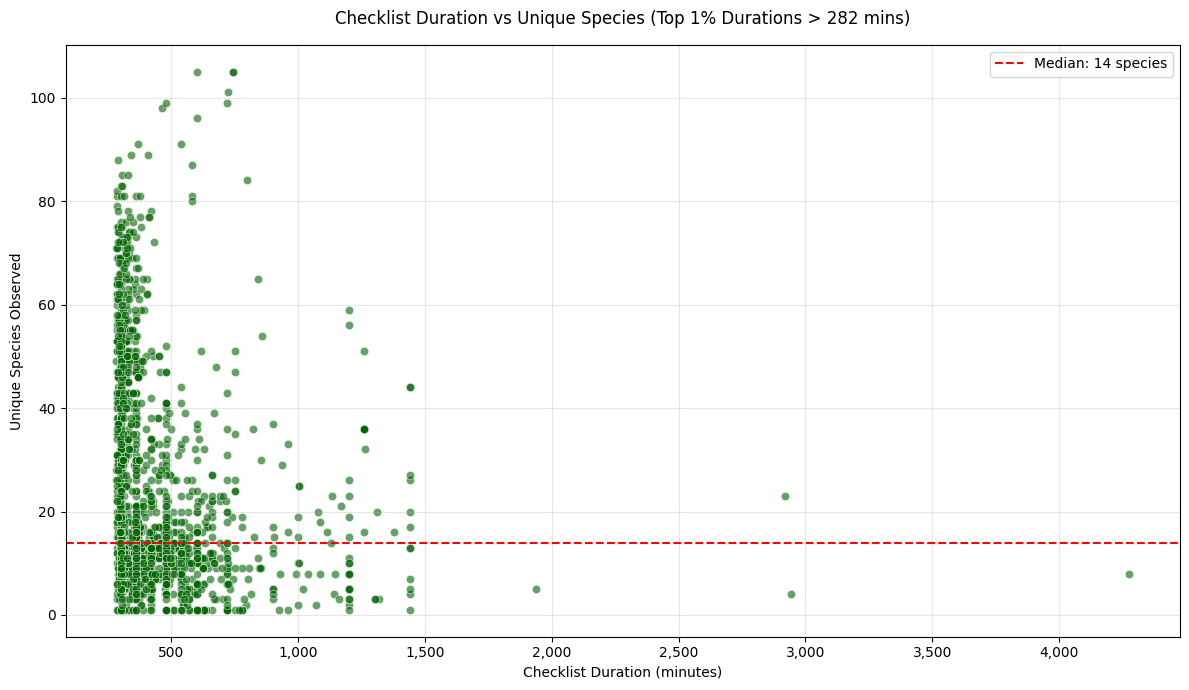

In [21]:
# Calculate 99th percentile cutoff
duration_cutoff = ebird['DURATION MINUTES'].quantile(0.99)

# Filter for extreme durations and group by checklist
extreme_checklists = (
    ebird[ebird['DURATION MINUTES'] > duration_cutoff]
    .groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        DURATION=('DURATION MINUTES', 'first'),  # Duration per checklist (should be consistent)
        UNIQUE_SPECIES=('COMMON NAME', 'nunique')  # Count of unique species
    )
)

# Create scatter plot
plt.figure(figsize=(12, 7))
plt.scatter(
    x=extreme_checklists['DURATION'],
    y=extreme_checklists['UNIQUE_SPECIES'],
    alpha=0.6,
    color='darkgreen',
    edgecolor='white',
    linewidth=0.5
)

# Formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title(f'Checklist Duration vs Unique Species (Top 1% Durations > {duration_cutoff:.0f} mins)', pad=15)
plt.xlabel('Checklist Duration (minutes)')
plt.ylabel('Unique Species Observed')
plt.grid(True, alpha=0.3)

# Add reference line for median species count
median_species = extreme_checklists['UNIQUE_SPECIES'].median()
plt.axhline(median_species, color='red', linestyle='--', 
            label=f'Median: {median_species:.0f} species')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Get top 50 longest-duration checklists
top_durations = (
    ebird.groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        CHECKLIST_ID=('SAMPLING EVENT IDENTIFIER', 'first'),
        OBERVER_ID=('OBSERVER ID', 'first'),
        DURATION_MIN=('DURATION MINUTES', 'first'),
        DISTANCE_KM=('EFFORT DISTANCE KM', 'first'),
        SPECIES_COUNT=('COMMON NAME', 'nunique'),
        NUMBER_OBSERVERS = ('NUMBER OBSERVERS', 'first'),
        PROTOCOL_TYPE = ('PROTOCOL TYPE', 'first'),
        LOCALITY=('LOCALITY', 'first'),
        OBSERVATION_DATE=('OBSERVATION DATE', 'first')
    )
    .nlargest(50, 'DURATION_MIN')
    .reset_index()
)

# Format output
top_durations[['CHECKLIST_ID', 'OBERVER_ID', 'OBSERVATION_DATE', 'DURATION_MIN', 'DISTANCE_KM', 'SPECIES_COUNT', 'NUMBER_OBSERVERS', 'PROTOCOL_TYPE', 'LOCALITY']]

,CHECKLIST_ID,OBERVER_ID,OBSERVATION_DATE,DURATION_MIN,DISTANCE_KM,SPECIES_COUNT,NUMBER_OBSERVERS,PROTOCOL_TYPE,LOCALITY
0,S90587093,obsr98133,2021-06-19,"4,277",66,8,1,Traveling,"Pope Farm conservancy, Verona US-WI 43.07716, ..."
1,S66640648,obsr284893,2020-04-04,"2,945",2,4,2,Traveling,Madison School Forest
2,S81328689,obsr1021298,2021-02-12,"2,919",26,23,1,Traveling,"404 Sunset Ct, Marshall US-WI 43.17190, -89.06602"
3,S84795319,obsr1079530,2020-05-17,"1,939",42,5,1,Traveling,"2653 Cambrian Cir, Fitchburg US-WI (42.9992,-8..."
4,S108618636,obsr2403332,2022-04-30,"1,440",NaN,26,1,Stationary,Home
5,S109132766,obsr1270053,2022-05-05,"1,440",NaN,20,1,Stationary,"8749 Bluff Valley Rd, Cross Plains US-WI 43.05..."
6,S136491768,obsr513738,2023-05-05,"1,440",5,44,1,Traveling,Yahara River/Lake Monona area
7,S136565779,obsr497290,2023-05-05,"1,440",5,44,1,Traveling,Yahara River/Lake Monona area
8,S171005998,obsr1041684,2024-04-26,"1,440",NaN,4,1,Stationary,"1826 Fordem Avenue, Madison, Wisconsin, US (43..."
9,S178742482,obsr4672312,2024-04-17,"1,440",26,13,1,Traveling,Home


##### Explore distance outlier

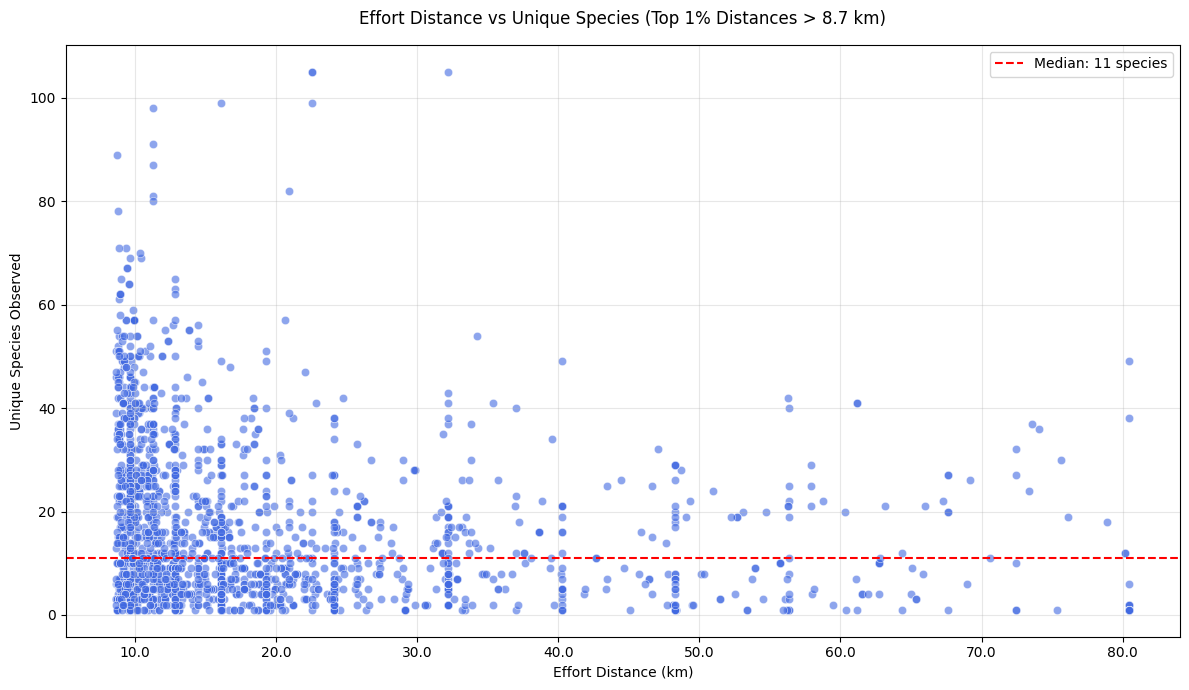

In [23]:
# Calculate 99th percentile cutoff for DISTANCE
distance_cutoff = ebird['EFFORT DISTANCE KM'].quantile(0.99)

# Filter for extreme distances and group by checklist
extreme_checklists = (
    ebird[ebird['EFFORT DISTANCE KM'] > distance_cutoff]
    .groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        DISTANCE=('EFFORT DISTANCE KM', 'first'),  # Distance per checklist
        UNIQUE_SPECIES=('COMMON NAME', 'nunique')   # Count of unique species
    )
)

# Create scatter plot
plt.figure(figsize=(12, 7))
plt.scatter(
    x=extreme_checklists['DISTANCE'],
    y=extreme_checklists['UNIQUE_SPECIES'],
    alpha=0.6,
    color='royalblue',
    edgecolor='white',
    linewidth=0.5
)

# Formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.1f}'))  # 1 decimal for distance
plt.title(f'Effort Distance vs Unique Species (Top 1% Distances > {distance_cutoff:.1f} km)', pad=15)
plt.xlabel('Effort Distance (km)')
plt.ylabel('Unique Species Observed')
plt.grid(True, alpha=0.3)

# Add reference line for median species count
median_species = extreme_checklists['UNIQUE_SPECIES'].median()
plt.axhline(median_species, color='red', linestyle='--', 
            label=f'Median: {median_species:.0f} species')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Get top 50 longest-distance checklists
top_distance = (
    ebird.groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        CHECKLIST_ID=('SAMPLING EVENT IDENTIFIER', 'first'),
        OBERVER_ID=('OBSERVER ID', 'first'),
        DURATION_MIN=('DURATION MINUTES', 'first'),
        DISTANCE_KM=('EFFORT DISTANCE KM', 'first'),
        SPECIES_COUNT=('COMMON NAME', 'nunique'),
        NUMBER_OBSERVERS = ('NUMBER OBSERVERS', 'first'),
        PROTOCOL_TYPE = ('PROTOCOL TYPE', 'first'),
        LOCALITY=('LOCALITY', 'first'),
        OBSERVATION_DATE=('OBSERVATION DATE', 'first')
    )
    .nlargest(50, 'DISTANCE_KM')
    .reset_index()
)

# Format output
top_distance[['CHECKLIST_ID', 'OBERVER_ID', 'OBSERVATION_DATE', 'DURATION_MIN', 'DISTANCE_KM', 'SPECIES_COUNT', 'NUMBER_OBSERVERS', 'PROTOCOL_TYPE', 'LOCALITY']]

,CHECKLIST_ID,OBERVER_ID,OBSERVATION_DATE,DURATION_MIN,DISTANCE_KM,SPECIES_COUNT,NUMBER_OBSERVERS,PROTOCOL_TYPE,LOCALITY
0,S107570093,obsr2253162,2022-04-20,180,80,38,2,Traveling,McDaniel Park
1,S21929533,obsr571951,2015-02-15,270,80,1,2,Traveling,"CTH V, 1/2 east of Lodi-Springfield Rd, Dane C..."
2,S21929565,obsr571951,2015-02-15,270,80,2,2,Traveling,"Hahn Rd, 4 miles due north of Waunakee, Dane C..."
3,S21929598,obsr571951,2015-02-15,270,80,2,2,Historical,"Madigan Rd, 1/2 mi north of CTH V, Dane Co, WI"
4,S21929615,obsr571951,2015-02-15,270,80,1,2,Historical,"Schumacher Rd, 1mi north of Hwy 19, Waunakee, WI"
5,S21929667,obsr571951,2015-02-15,270,80,1,2,Historical,"Lueth Rd and CTH Y, Roxbury, WI"
6,S21929825,obsr571951,2015-02-15,240,80,1,2,Traveling,"just west of Cuba Valley Rd and Schumacher Rd,..."
7,S21929846,obsr571951,2015-02-15,240,80,1,2,Traveling,"CTH V, 1/2 east of Lodi-Springfield Rd, Dane C..."
8,S21929881,obsr571951,2015-02-15,240,80,1,2,Traveling,"Madigan Rd, 1/2 mi north of CTH V, Dane Co, WI"
9,S21929898,obsr571951,2015-02-15,240,80,1,2,Traveling,"Hahn Rd at 100 Mile Grove Rd, Waunakee, WI"


##### Explore duration and distance after removing outlier

In [25]:
ebird.groupby('PROTOCOL TYPE')['DURATION MINUTES'].describe()

,count,mean,std,min,25%,50%,75%,max
PROTOCOL TYPE,,,,,,,,
Area,"3,942",80,72,5,55,60,90,540
Banding,471,288,63,45,240,285,330,420
Historical,"9,392",80,68,1,28,70,120,480
Incidental,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nocturnal Flight Call Count,198,264,193,1,50,300,360,651
PROALAS,5,30,0,30,30,30,30,30
Rusty Blackbird Spring Migration Blitz,"2,692",85,53,2,45,75,120,240
Stationary,"885,492",41,64,1,13,25,49,"1,440"
Traveling,"3,142,390",87,64,1,43,75,118,"4,277"


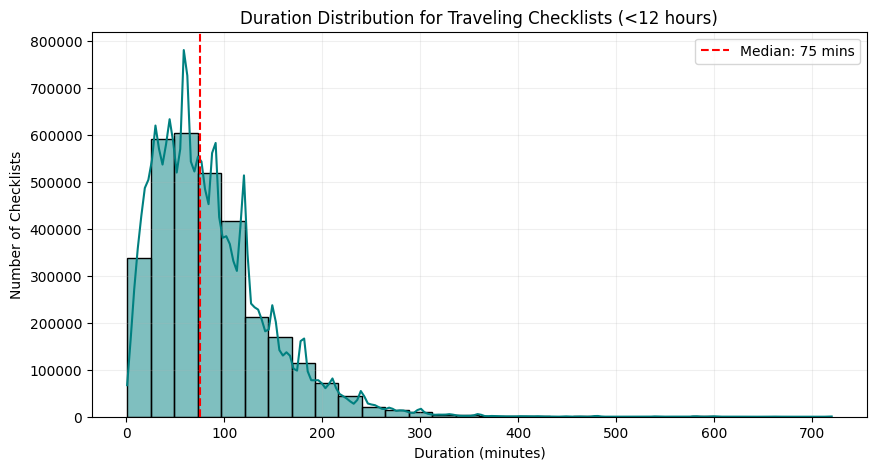

In [26]:
# Filter for Traveling protocol and reasonable durations
traveling_durations = ebird[
    (ebird['PROTOCOL TYPE'] == 'Traveling') & 
    (ebird['DURATION MINUTES'] <= 720)
]['DURATION MINUTES']

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(traveling_durations, bins=30, kde=True, color='teal')
plt.title('Duration Distribution for Traveling Checklists (<12 hours)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Checklists')
plt.grid(alpha=0.2)

# Annotate key stats
median = traveling_durations.median()
plt.axvline(median, color='red', linestyle='--', 
            label=f'Median: {median:.0f} mins')
plt.legend()

plt.show()

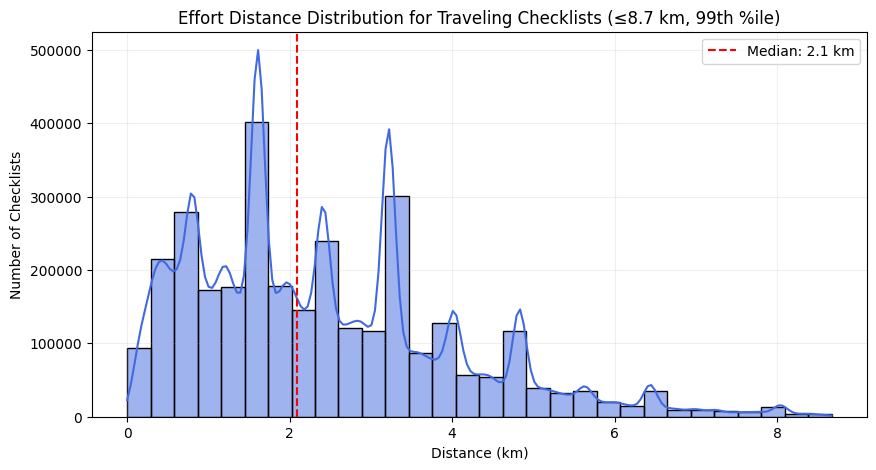

In [27]:
# Calculate 99th percentile cutoff for distance
distance_cutoff = ebird['EFFORT DISTANCE KM'].quantile(0.99)

# Filter for Traveling protocol and non-extreme distances
traveling_distances = ebird[
    (ebird['PROTOCOL TYPE'] == 'Traveling') & 
    (ebird['EFFORT DISTANCE KM'] <= distance_cutoff)
]['EFFORT DISTANCE KM']

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(traveling_distances, bins=30, kde=True, color='royalblue')
plt.title(f'Effort Distance Distribution for Traveling Checklists (≤{distance_cutoff:.1f} km, 99th %ile)')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Checklists')
plt.grid(alpha=0.2)

# Annotate key stats
median = traveling_distances.median()
plt.axvline(median, color='red', linestyle='--', 
            label=f'Median: {median:.1f} km')
plt.legend()

plt.show()

### Describe PRISM Data

In [ ]:
# Data range 2015-01-01 to 2025-01-31, Dane County, WI
# Mean temperature is statsistically significant increasing by 0.273°F per year

In [37]:
prism_WI_dane_county.head()

,Date,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F)
0,2015-01-01,0,1,10,18
1,2015-01-02,0,13,21,30
2,2015-01-03,0,14,23,31
3,2015-01-04,0,19,26,32
4,2015-01-05,0,-9,5,20


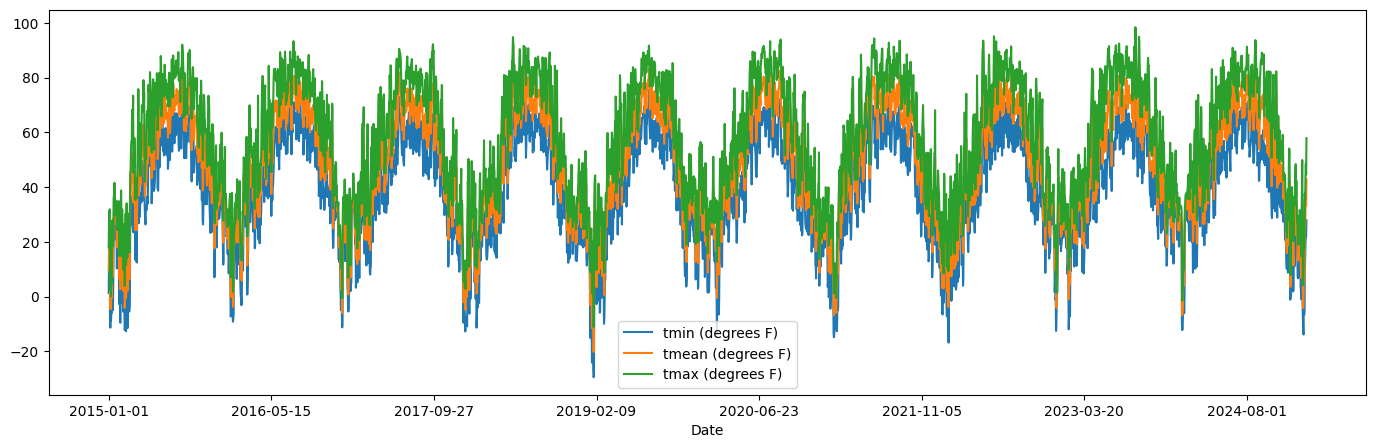

In [38]:
prism_WI_dane_county.plot(x='Date', y=['tmin (degrees F)', 'tmean (degrees F)', 'tmax (degrees F)'], kind='line', figsize=(17, 5))
plt.show()

In [46]:
# is mean temperature increasing YoY?

# Convert string dates to datetime
prism_WI_dane_county['Date'] = pd.to_datetime(prism_WI_dane_county['Date'])

# Now calculate numeric dates for regression
prism_WI_dane_county['date_numeric'] = (
    prism_WI_dane_county['Date'] - prism_WI_dane_county['Date'].min()
).dt.days

# Calculate linear trend for mean temperature
slope, intercept, r_value, p_value, std_err = linregress(
    x=prism_WI_dane_county['date_numeric'],
    y=prism_WI_dane_county['tmean (degrees F)']
)

# Calculate trend line
trend_line = intercept + slope * prism_WI_dane_county['date_numeric']

print(
    f"Mean Temperature Trend: {slope*365:.3f}°F per year\n"
    f"Statistical Significance (p-value): {p_value:.5f}\n"
    f"R-squared: {r_value**2:.3f}"
)

Mean Temperature Trend: 0.273°F per year
Statistical Significance (p-value): 0.01841
R-squared: 0.002


### Enrich Dataset with More Info like Time, Weather

In [52]:
ebird_climate.head()


,GLOBAL UNIQUE IDENTIFIER,LAST EDITED DATE,TAXONOMIC ORDER,CATEGORY,TAXON CONCEPT ID,COMMON NAME,SCIENTIFIC NAME,SUBSPECIES COMMON NAME,SUBSPECIES SCIENTIFIC NAME,EXOTIC CODE,OBSERVATION COUNT,BREEDING CODE,BREEDING CATEGORY,BEHAVIOR CODE,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,IBA CODE,BCR CODE,USFWS CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,OBSERVER ID,SAMPLING EVENT IDENTIFIER,PROTOCOL TYPE,PROTOCOL CODE,PROJECT CODE,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,NUMBER OBSERVERS,ALL SPECIES REPORTED,GROUP IDENTIFIER,HAS MEDIA,APPROVED,REVIEWED,REASON,TRIP COMMENTS,SPECIES COMMENTS,HOUR,DAY_OF_WEEK,MONTH,IS_GLOBAL_BIG_DAY,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F),date_numeric
0,URN:CornellLabOfOrnithology:EBIRD:OBS294566730,2017-07-17 13:48:19,8209,spuh,avibase-CA08045E,Accipitrine hawk sp. (former Accipiter sp.),Aerospiza/Tachyspiza/Accipiter/Astur sp.,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,US-WI_3635,23,NaN,NaN,WI - Prairie du Sac Wollersheim Winery,L3187307,P,43,-90,2015-01-31,15:00:00,obsr213338,S21647178,Stationary,P21,EBIRD,20,NaN,NaN,4,1,NaN,0,1,0,NaN,NaN,NaN,15,Saturday,January,False,0,12,19,26,30
1,URN:CornellLabOfOrnithology:EBIRD:OBS293977598,2021-03-30 02:26:51.250642,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Dyreson Road Bridge,L2720718,P,43,-89,2015-01-30,10:27:00,obsr384920,S21600893,Stationary,P21,EBIRD,4,NaN,NaN,2,1,G1129663,0,1,0,NaN,"<br />Submitted from BirdLog NA for iOS, versi...",NaN,10,Friday,January,False,0,12,23,34,29
2,URN:CornellLabOfOrnithology:EBIRD:OBS294098919,2021-04-01 21:33:26.357322,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Babcock County Park,L662891,H,43,-89,2015-01-30,13:15:00,obsr151037,S21609879,Stationary,P21,EBIRD,30,NaN,NaN,4,1,G1129804,0,1,0,NaN,NaN,NaN,13,Friday,January,False,0,12,23,34,29
3,URN:CornellLabOfOrnithology:EBIRD:OBS292844052,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-23,16:32:00,obsr438170,S21510913,Stationary,P21,EBIRD,59,NaN,NaN,2,1,NaN,0,1,0,NaN,With Jude Vickery Submitted from BirdLog NA f...,NaN,16,Friday,January,False,0,25,29,33,22
4,URN:CornellLabOfOrnithology:EBIRD:OBS294268996,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-31,11:00:00,obsr381800,S21623656,Traveling,P22,EBIRD,40,3,NaN,1,1,NaN,0,1,0,NaN,NaN,NaN,11,Saturday,January,False,0,12,19,26,30


In [31]:
# Extract temporal features
ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour
ebird['DAY_OF_WEEK'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.day_name()
ebird['MONTH'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.month_name()

/var/folders/3w/875q3kbn2blb9zwp1zjfrhfc0000gn/T/ipykernel_4910/3493306810.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour


In [33]:
# Global Big Day dates (second Saturday in May each year)
big_day_dates = {
    2015: '2015-05-09',
    2016: '2016-05-14',
    2017: '2017-05-13',
    2018: '2018-05-12',
    2019: '2019-05-11',
    2020: '2020-05-09',
    2021: '2021-05-08',
    2022: '2022-05-14',
    2023: '2023-05-13',
    2024: '2024-05-11',
    2025: '2025-05-10'
}

# Convert observation dates to datetime if not already
ebird['OBSERVATION DATE'] = pd.to_datetime(ebird['OBSERVATION DATE'])

# Create new column marking Global Big Day
ebird['IS_GLOBAL_BIG_DAY'] = ebird['OBSERVATION DATE'].isin(pd.to_datetime(list(big_day_dates.values())))

In [ ]:
# join ebird with prism_WI_dane_county
ebird_climate = pd.merge(ebird, prism_WI_dane_county, left_on='OBSERVATION DATE', right_on='Date', how='left')
ebird_climate = ebird_climate.drop(columns=['Date'])

### Exploratory Analysis

In [ ]:
# Summary

# Protocol type affects duration distribution:
# - Traveling: 75 min (median)
# - Stationary: 25 min (median)


In [12]:
# Get median durations for Traveling and Stationary protocols
median_durations = (
    ebird_numeric_count_only[
        ebird_numeric_count_only['PROTOCOL TYPE'].isin(['Traveling', 'Stationary'])
    ]
    .groupby('PROTOCOL TYPE')['DURATION MINUTES']
    .median()
    .round(0)
)

# Generate formatted output
print(
    f"Protocol type affects duration distribution:\n"
    f"- Traveling: {median_durations['Traveling']:.0f} min (median)\n"
    f"- Stationary: {median_durations['Stationary']:.0f} min (median)"
)

Protocol type affects duration distribution:
- Traveling: 75 min (median)
- Stationary: 25 min (median)


/var/folders/3w/875q3kbn2blb9zwp1zjfrhfc0000gn/T/ipykernel_39606/3493306810.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour


#### Trend Analysis

##### Does birder in Dane County's favorite site changes every year between 2018-2023?

** favoriate site defined as highest checklist submitted

In [118]:
(
    ebird.groupby(['YEAR', 'LOCALITY'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .groupby('YEAR', group_keys=False)
    .nlargest(3)
    .reset_index(name='CHECKLIST COUNT')
)

,YEAR,LOCALITY,CHECKLIST COUNT
0,2018,UW Madison Arboretum (general),850
1,2018,F/L (private),453
2,2018,2613 Waltham Rd.,431
3,2019,UW Madison Arboretum (general),844
4,2019,2613 Waltham Rd.,566
5,2019,F/L (private),408
6,2020,UW Madison Arboretum (general),1017
7,2020,Owen Conservation Park,833
8,2020,Cherokee Marsh Conservation Park--North Unit,779
9,2021,UW Madison Arboretum (general),1216


##### Has there been an increasing number of checklists submitted by birders in Dane?

<Axes: xlabel='OBSERVATION DATE'>

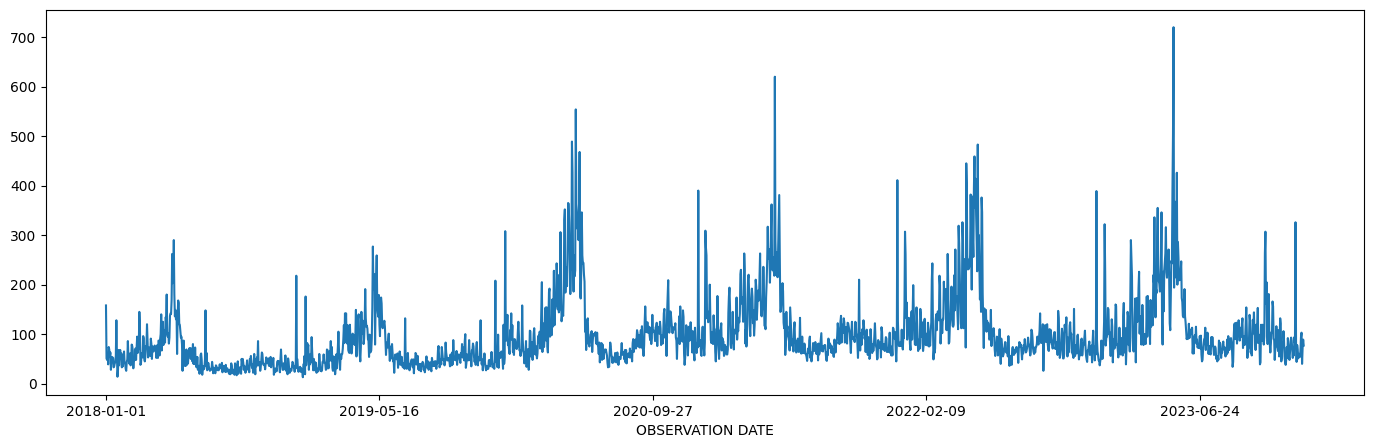

In [65]:
# unique checklist submitted by date
ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique().sort_index().plot(figsize=(17, 5))

In [54]:
ts = ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique()
stat, p = normaltest(ts)  # D'Agostino-Pearson test
print(f"Normality p-value: {p:.4f}")  # p < 0.05 → Not Gaussian

Normality p-value: 0.0000


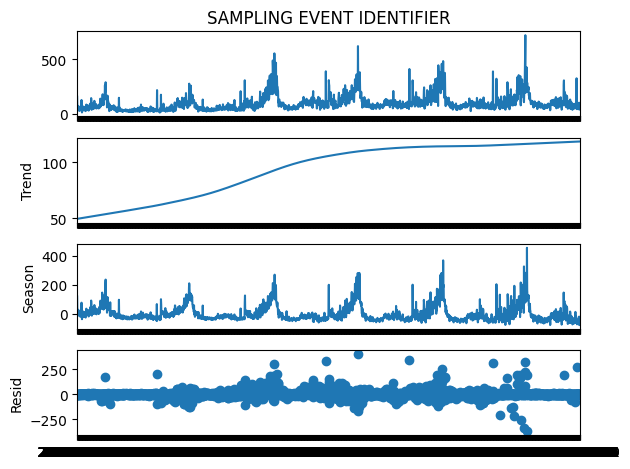

Trend slope: 0.035 (checklists/day), p-value: 0.0000


In [73]:
# there is a stats sig increase in the number of checklists submitted over time between 2018 and 2023

from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Prepare daily counts
ts = ebird.groupby('OBSERVATION DATE')['SAMPLING EVENT IDENTIFIER'].nunique()

# Decompose trend + seasonality
stl = STL(ts, period=365, robust=True).fit()  # 365 for yearly seasonality
stl.plot()
plt.show()

# Trend slope (simple linear regression on trend component)
from scipy.stats import linregress
trend_slope, _, _, pvalue, _ = linregress(
    x=np.arange(len(stl.trend)),
    y=stl.trend.dropna()
)
print(f"Trend slope: {trend_slope:.3f} (checklists/day), p-value: {pvalue:.4f}")

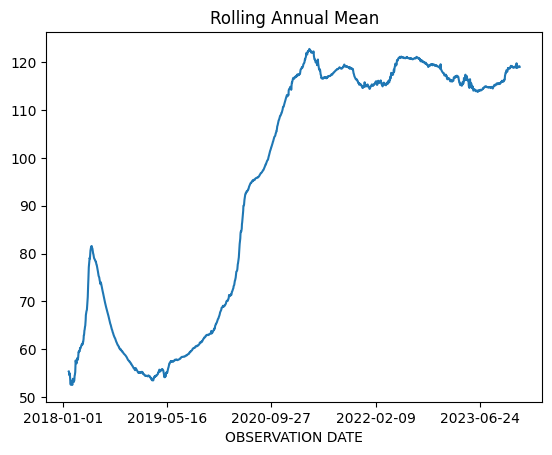

In [74]:
# Plot 365-day rolling mean to visualize trend
ts.rolling(365, min_periods=30).mean().plot(title="Rolling Annual Mean")
plt.show()

In [ ]:
# Compare current year to previous year (YoY change)
ts.index = pd.to_datetime(ts.index)  # Ensure index is datetime
yearly_growth = ts.groupby(ts.index.year).sum().pct_change().dropna()
print(f"Yearly growth rates:\n{yearly_growth}")

Yearly growth rates:
OBSERVATION DATE
2019    0.170101
2020    0.786492
2021    0.002333
2022    0.019975
2023    0.011690
Name: SAMPLING EVENT IDENTIFIER, dtype: float64


##### Has there been an increasing number of oberseved specieces submitted through ebird in Dane?

<Axes: xlabel='OBSERVATION DATE'>

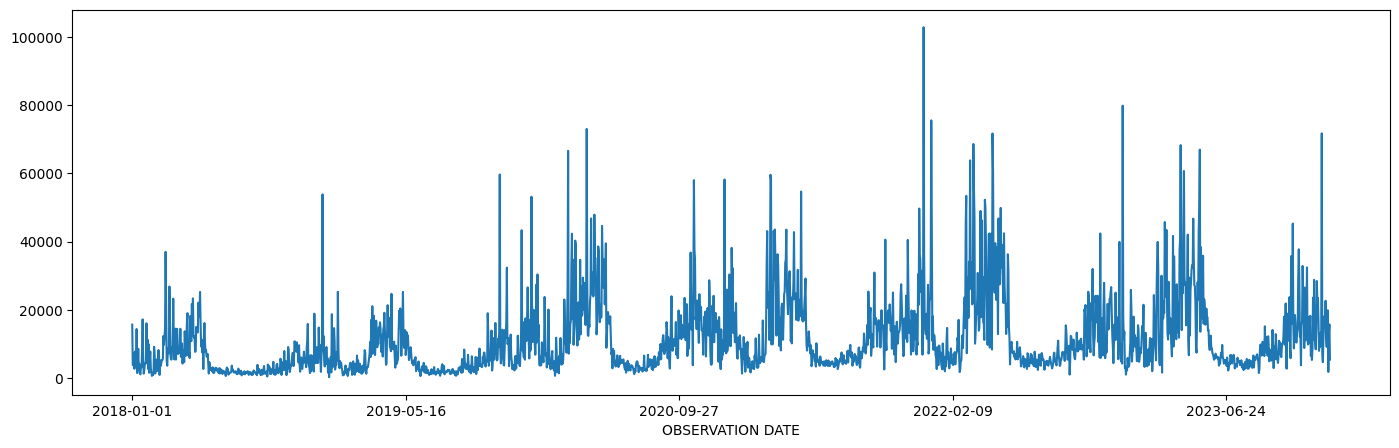

In [ ]:
ebird.groupby('OBSERVATION DATE')['OBSERVATION COUNT'].sum().sort_index().plot(figsize=(17, 5))

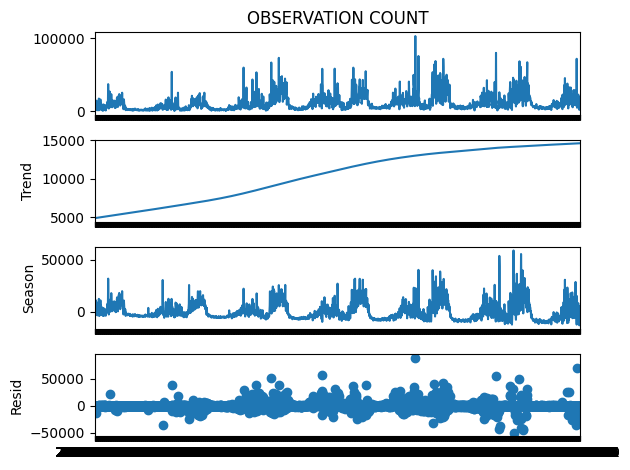

Trend slope: 5.000 (observed count/day), p-value: 0.0000


In [76]:
# yes - there is a stats sig increase in observed bird count over time between 2018 and 2023

# Prepare daily counts
ts = ebird.groupby('OBSERVATION DATE')['OBSERVATION COUNT'].sum()

# Decompose trend + seasonality
stl = STL(ts, period=365, robust=True).fit()  # 365 for yearly seasonality
stl.plot()
plt.show()

# Trend slope (simple linear regression on trend component)
from scipy.stats import linregress
trend_slope, _, _, pvalue, _ = linregress(
    x=np.arange(len(stl.trend)),
    y=stl.trend.dropna()
)
print(f"Trend slope: {trend_slope:.3f} (observed count/day), p-value: {pvalue:.4f}")

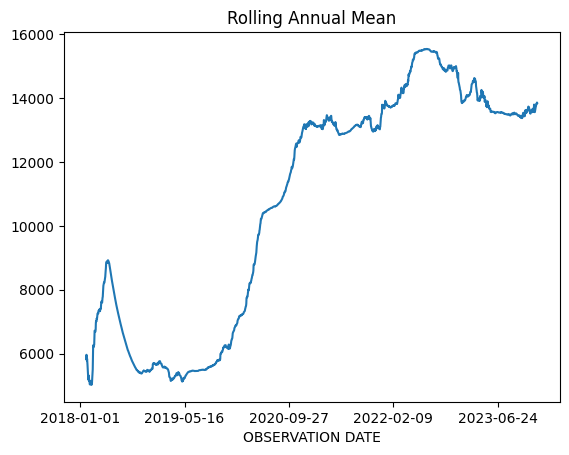

In [77]:
# Plot 365-day rolling mean to visualize trend
ts.rolling(365, min_periods=30).mean().plot(title="Rolling Annual Mean")
plt.show()

In [78]:
# Compare current year to previous year (YoY change)
ts.index = pd.to_datetime(ts.index)  # Ensure index is datetime
yearly_growth = ts.groupby(ts.index.year).sum().pct_change().dropna()
print(f"Yearly growth rates:\n{yearly_growth}")

Yearly growth rates:
OBSERVATION DATE
2019    0.149367
2020    1.044420
2021    0.037510
2022    0.023203
2023   -0.017213
Name: OBSERVATION COUNT, dtype: float64


##### Has there been shifts in birding habits across years?

* Time of day: consistent pattern, but observed spike in checklist submitted in 2020, checklist submitted almost doubled staring from 2020 when comparing to 2019.
* Day of Week: consistent

<Figure size 1200x600 with 0 Axes>

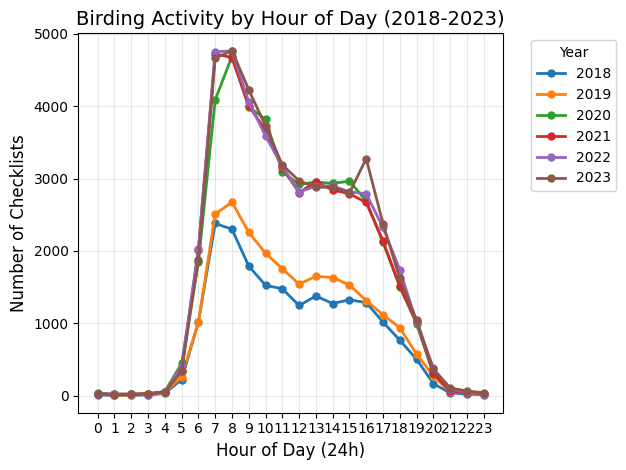

In [124]:
plt.figure(figsize=(12, 6))

# Group by year and hour, then count checklists
hourly_by_year = (
    ebird.groupby(['YEAR', 'HOUR'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Plot each year's line
hourly_by_year.plot(kind='line', marker='o', linewidth=2, markersize=5)

# Customize plot
plt.title('Birding Activity by Hour of Day (2018-2023)', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Checklists', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

# Move legend outside
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [126]:
# Count unique checklists per year
yearly_counts = ebird.groupby('YEAR')['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage of total
yearly_pct = (yearly_counts / yearly_counts.sum() * 100).round(1)

# Combine into a clean DataFrame
result = pd.DataFrame({
    'Checklist Count': yearly_counts,
    'Percentage (%)': yearly_pct
})

print(result)

      Checklist Count  Percentage (%)
YEAR                                 
2018            20094             9.4
2019            23512            11.0
2020            42004            19.6
2021            42102            19.7
2022            42943            20.1
2023            43445            20.3


<Figure size 1200x500 with 0 Axes>

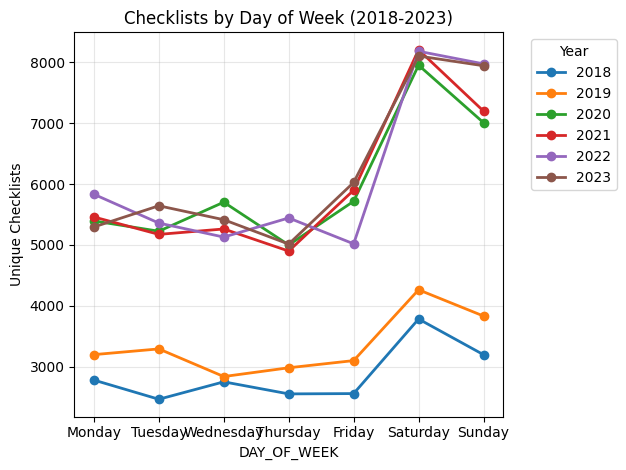

In [127]:
# Count checklists by year and day of week
dow_counts = (
    ebird.groupby(['YEAR', 'DAY_OF_WEEK'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Reorder days (Monday to Sunday)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.loc[dow_order]

# Plot
plt.figure(figsize=(12, 5))
dow_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Checklists by Day of Week (2018-2023)')
plt.ylabel('Unique Checklists')
plt.grid(alpha=0.3)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

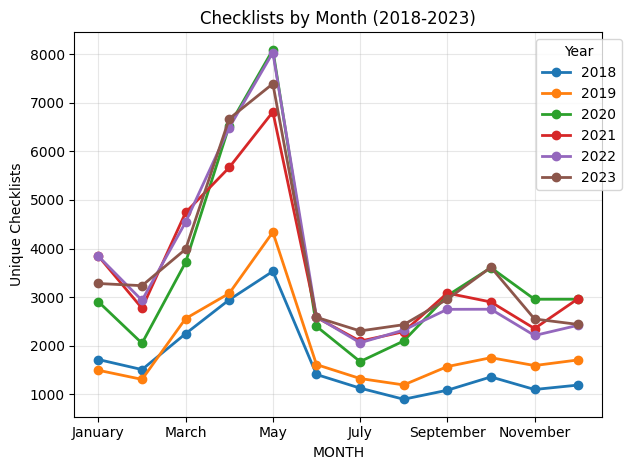

In [128]:
# Count checklists by year and month
month_counts = (
    ebird.groupby(['YEAR', 'MONTH'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = month_counts.loc[month_order]

# Plot
plt.figure(figsize=(12, 5))
month_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Checklists by Month (2018-2023)')
plt.ylabel('Unique Checklists')
plt.grid(alpha=0.3)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

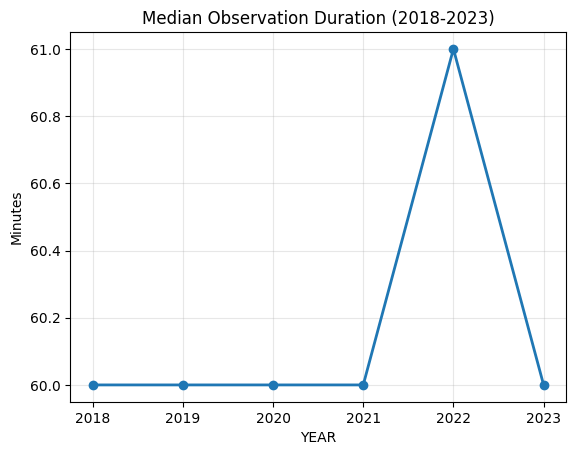

In [129]:
duration = (
    ebird.groupby('YEAR')['DURATION MINUTES']
    .median()
    .to_frame('Median Duration (min)')
)

plt.figure(figsize=(8, 4))
duration.plot(kind='line', marker='o', linewidth=2, legend=False)
plt.title('Median Observation Duration (2018-2023)')
plt.ylabel('Minutes')
plt.grid(alpha=0.3)
plt.xticks(duration.index)
plt.show()

<Figure size 800x400 with 0 Axes>

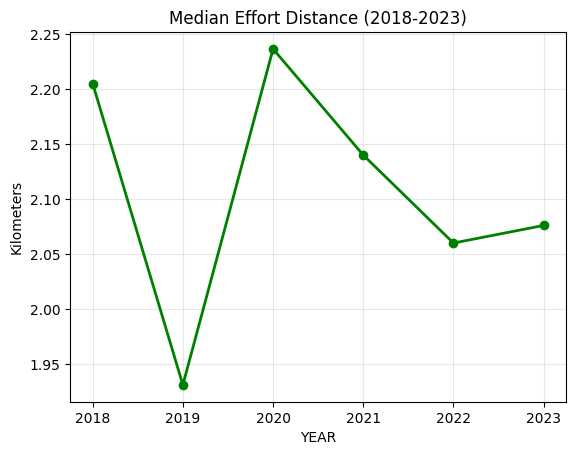

In [130]:
distance = (
    ebird.groupby('YEAR')['EFFORT DISTANCE KM']
    .median()
    .to_frame('Median Distance (km)')
)

plt.figure(figsize=(8, 4))
distance.plot(kind='line', marker='o', linewidth=2, color='green', legend=False)
plt.title('Median Effort Distance (2018-2023)')
plt.ylabel('Kilometers')
plt.grid(alpha=0.3)
plt.xticks(distance.index)
plt.show()

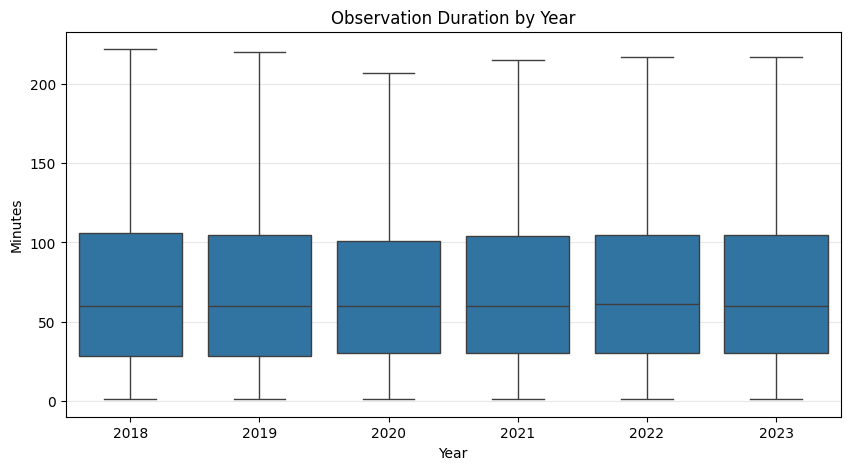

In [132]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=ebird,
    x='YEAR',
    y='DURATION MINUTES',
    showfliers=False  # Exclude outliers for cleaner plot
)
plt.title('Observation Duration by Year')
plt.xlabel('Year')
plt.ylabel('Minutes')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Limit to only required columns

In [ ]:
cols = ['OBSERVATION DATE', 'COMMON NAME', 'OBSERVATION COUNT', 'COUNTRY', 'STATE', 'COUNTY', 'LOCALITY', 'LATITUDE', 'LONGITUDE']
ebird = ebird[cols]

In [ ]:
ebird['OBSERVATION DATE'] = pd.to_datetime(ebird['OBSERVATION DATE'])
ebird['YEAR'] = ebird['OBSERVATION DATE'].dt.year
ebird['MONTH'] = ebird['OBSERVATION DATE'].dt.month

In [ ]:
ebird